# Out-of-sample evaluation — Copal PV models on Elia's Luxembourg-province PV series

**EnerTEF · TEF-EV (Leneda, Luxembourg) · Service 2 — companion to `ECC_PV_Forecasting.ipynb`**

The shipped package (`Data/models/`) was trained and tested on one plant, the Copal Supermarket energy
community, and its hold-out is 60 winter days. This notebook runs the **packaged models** — the LightGBM
text files and `model_config.json` exactly as published — and asks the two questions that hold-out cannot
answer:

1. **Does the skill survive spring, summer and autumn?** The hold-out ends on 18 Jan 2026 and the Copal
   export stops there; the Elia series runs to 30 Sep 2026.
2. **How far does it transfer?** Another data source — a regional aggregate instead of one plant.

**Test data** — [Elia Open Data, ODS032](https://opendata.elia.be/explore/dataset/ods032/), region
`Luxembourg` (the Belgian province bordering the Grand Duchy, about 100 km west of Copal): 15-minute
measured and upscaled PV generation, plus Elia's own day-ahead forecast. Timestamps are interval starts in
UTC, the same convention as the Leneda `Started at` column.

## Protocol — fixed before any result was looked at

| | |
|---|---|
| Models | the six `pv_<block>_<quantile>.txt` boosters and `model_config.json` exactly as shipped — no retraining, no tuning |
| Series | Elia measured MW ÷ monitored capacity MW × 973.81 kWc, i.e. **Copal-equivalent kW**: the same scale as the training features, and nMAE is a % of capacity |
| Test window | from the training cut-off (19 Nov 2025 22:45 UTC) to 30 Sep 2026. Earlier days share their weather with the Copal training set, so they are not scored |
| Two sub-windows | the first 60 days are the **hold-out window** (same sky, other source — isolates the transfer effect); the rest, 19 Jan → 30 Sep 2026, is **new** |
| Envelope | refitted on Elia data inside the Copal training window only, with the shipped estimator (slope). The Copal envelope as-is is run as a sensitivity |
| Features and scoring | the shipped feature builder: the model's own feature list including the Open-Meteo previous-run weather, the same quantile clipping / sorting / cap, the same daytime slot set, 24 h persistence as the reference |
| Gate | before anything is scored on Elia, this code must reproduce the current release's published Copal hold-out numbers in `metrics.json` |
| Reference | Elia's own 6 PM day-ahead forecast — both it and these models are weather-driven |

Source of the test data: Elia Open Data (Elia Open Data Licence). The notebook downloads it from the Elia
API at run time and caches it in `Data/external/` (git-ignored).


## 1 · Setup

The method constants are those of `ECC_PV_Forecasting.ipynb` §1. The models were trained at the Copal
location, so the clear-sky features of the Elia series are also computed there; the regional series is
treated as "a Copal-sized plant behaving like the province".

In [1]:
import json
import time
import warnings
from pathlib import Path
from urllib.error import HTTPError
from urllib.parse import urlencode
from urllib.request import Request, urlopen

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
MODEL_DIR = ROOT / "Data" / "models"
DATA_CSV = ROOT / "Data" / "ECC_master_PV_EMOB1_EMOB2_15min.csv"
CACHE_DIR = ROOT / "Data" / "external"
for path in (MODEL_DIR / "model_config.json", MODEL_DIR / "metrics.json", DATA_CSV):
    if not path.is_file():
        raise FileNotFoundError(f"{path} not found — start Jupyter from the repository root.")

# Plant and method constants — as in ECC_PV_Forecasting.ipynb §1
CAPACITY_KWC = 973.81
LATITUDE, LONGITUDE = 49.70673, 6.48714
SLOT = pd.Timedelta(minutes=15)
KCS_MAX = 1.3                    # clear-sky index cap
NIGHT_GHI_WM2 = 10.0             # below this clear-sky GHI a slot counts as night
ENVELOPE_MIN_GHI_WM2 = 200.0     # well-lit slots used to fit the envelope slope
ENVELOPE_QUANTILE = 0.995        # envelope slope = this quantile of PV / clear-sky GHI
ENV_FLOOR_KW = 0.005 * CAPACITY_KWC   # below this clear-sky power a slot is dawn/dusk: no clear-sky index
QUANTILES = {"q10": 0.1, "q50": 0.5, "q90": 0.9}
MISSING = -1.0                   # missing-value code (with companion indicator features)
NWP_LAG_H = 6.0                  # a weather run is usable 6 h after its nominal initialisation

# ---- the shipped artefacts -------------------------------------------------------------------------
CONFIG = json.loads((MODEL_DIR / "model_config.json").read_text(encoding="utf-8"))
metrics = json.loads((MODEL_DIR / "metrics.json").read_text(encoding="utf-8"))
COPAL_ENV = CONFIG["envelope"]                                          # the shipped slope envelope
BLOCKS = {b: {"leads_h": tuple(v["leads_h"]), "issue_hours_utc": v["issue_hours_utc"],
              "features": v["features"], "band_offsets": v["band_offsets"]}
          for b, v in CONFIG["blocks"].items()}
BOOSTERS = {b: {q: lgb.Booster(model_file=str(MODEL_DIR / f)) for q, f in spec["quantile_files"].items()}
            for b, spec in CONFIG["blocks"].items()}
FEATURE_NAMES = BLOCKS["intraday"]["features"]
assert all(BLOCKS[b]["features"] == FEATURE_NAMES for b in BLOCKS)

# Windows
TRAIN_END = pd.Timestamp(CONFIG["windows"]["train_before"])             # training cut-off = start of the hold-out
COPAL_LAST = pd.Timestamp(CONFIG["windows"]["band_calibration"][1])     # last Copal observation
ELIA_START = pd.Timestamp("2023-10-11 22:00", tz="UTC")                 # same history depth as the Copal training set
ELIA_END = pd.Timestamp("2026-10-01 00:00", tz="UTC")                   # exclusive; pinned so the run is reproducible
NWP_START, NWP_END = pd.Timestamp("2024-01-01", tz="UTC"), ELIA_END
WINDOWS = (f"hold-out window ({TRAIN_END:%d %b %Y} → {COPAL_LAST:%d %b %Y})",
           f"new period ({COPAL_LAST + pd.Timedelta(days=1):%d %b} → {ELIA_END - pd.Timedelta(days=1):%d %b %Y})")

print(f"packaged models: {CONFIG['algorithm']} · lightgbm {CONFIG['environment']['lightgbm']} · "
      f"{len(BOOSTERS)} blocks × {len(QUANTILES)} quantiles · {len(FEATURE_NAMES)} features")
print(f"test window {TRAIN_END:%d %b %Y %H:%M} → {ELIA_END:%d %b %Y} UTC · capacity {CAPACITY_KWC} kWc · "
      f"Copal envelope {COPAL_ENV['kw_per_wm2']} kW per W/m², cap {COPAL_ENV['max_kw']} kW")


packaged models: lightgbm quantile regression (3 quantiles per block) · lightgbm 4.7.0 · 2 blocks × 3 quantiles · 24 features
test window 19 Nov 2025 22:45 → 01 Oct 2026 UTC · capacity 973.81 kWc · Copal envelope 0.799626 kW per W/m², cap 662.723 kW


## 2 · Data

**Elia** — one request to the Elia open-data API for the Luxembourg province, from the start of the Copal
training window to 30 Sep 2026, cached on disk. The checks below are the ones that would invalidate a
comparison: duplicated or missing intervals, missing values in the test window, and what `loadfactor` and
`monitoredcapacity` really mean (the installed capacity in the province grew from about 180 MW to 368 MW over
the period, so raw MW must never be compared across time).

**Copal** — the Leneda export, loaded as in `ECC_PV_Forecasting.ipynb`; only used for the gate in §4 and for
the "does the series track Copal" check in §3.

In [2]:
ELIA_URL = "https://opendata.elia.be/api/explore/v2.1/catalog/datasets/ods032/exports/csv"
ELIA_REGION = "Luxembourg"
ELIA_FIELDS = ["datetime", "measured", "monitoredcapacity", "loadfactor",
               "dayaheadforecast", "dayaheadconfidence10", "dayaheadconfidence90"]

cache = CACHE_DIR / f"elia_ods032_{ELIA_REGION.lower()}_{ELIA_START:%Y%m%d}_{ELIA_END:%Y%m%d}.csv"
if not cache.is_file():
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    query = urlencode({
        "where": (f"region=\"{ELIA_REGION}\" AND datetime>=date'{ELIA_START:%Y-%m-%dT%H:%M:%SZ}' "
                  f"AND datetime<date'{ELIA_END:%Y-%m-%dT%H:%M:%SZ}'"),
        "select": ",".join(ELIA_FIELDS), "order_by": "datetime",
    })
    with urlopen(Request(f"{ELIA_URL}?{query}", headers={"User-Agent": "enertef-pv-evaluation"}), timeout=300) as resp:
        payload = resp.read()
    tmp = cache.with_suffix(".part")
    tmp.write_bytes(payload)
    tmp.replace(cache)  # the cache only ever holds a complete download
    print(f"downloaded {len(payload) / 1e6:.1f} MB from Elia → {cache.relative_to(ROOT).as_posix()}")
else:
    print(f"using cached {cache.relative_to(ROOT).as_posix()}")

raw = pd.read_csv(cache, sep=";", encoding="utf-8-sig")
elia = (raw.assign(ts_utc=pd.to_datetime(raw["datetime"], utc=True)).drop(columns="datetime")
        .set_index("ts_utc").sort_index())

full_grid = pd.date_range(elia.index[0], elia.index[-1], freq=SLOT)
test_part = elia.loc[TRAIN_END:]
qa = pd.Series({
    "first interval (UTC)": elia.index[0],
    "last interval (UTC)": elia.index[-1],
    "intervals": len(elia),
    "duplicate timestamps": int(elia.index.duplicated().sum()),
    "gaps on the 15-min grid": len(full_grid) - elia.index.nunique(),
    "missing measured (whole file)": int(elia.measured.isna().sum()),
    "missing measured (test window)": int(test_part.measured.isna().sum()),
    "missing day-ahead forecast (test window)": int(test_part.dayaheadforecast.isna().sum()),
    "max |loadfactor − 100·measured/capacity| (%)": round(float((elia.loadfactor - 100 * elia.measured / elia.monitoredcapacity).abs().max()), 4),
    "monitored capacity, first → last (MW)": f"{elia.monitoredcapacity.iloc[0]:.0f} → {elia.monitoredcapacity.iloc[-1]:.0f}",
    "peak measured in the test window (MW)": round(float(test_part.measured.max()), 1),
})
display(qa.to_frame("value"))
assert qa["duplicate timestamps"] == 0 and qa["gaps on the 15-min grid"] == 0
assert qa["missing measured (test window)"] == 0 and qa["missing day-ahead forecast (test window)"] == 0

# Copal-equivalent kW: capacity fraction × Copal's nameplate (the scale of the training features)
elia_pv = (elia.measured / elia.monitoredcapacity * CAPACITY_KWC).clip(0.0, CAPACITY_KWC).rename("pv_kw")
ELIA_DA = pd.DataFrame({
    "p10": elia.dayaheadconfidence10, "p50": elia.dayaheadforecast, "p90": elia.dayaheadconfidence90,
}).div(elia.monitoredcapacity, axis=0) * CAPACITY_KWC

# Copal, as loaded by the original notebook §2
copal_raw = pd.read_csv(DATA_CSV, usecols=["Started at", "PV_TotalProduction_kW"])
copal_ts = pd.to_datetime(copal_raw["Started at"], utc=True, errors="coerce", format="ISO8601")
copal_pv = pd.Series(pd.to_numeric(copal_raw["PV_TotalProduction_kW"], errors="coerce").to_numpy(),
                     index=pd.DatetimeIndex(copal_ts, name="ts_utc"))
copal_pv = copal_pv[copal_pv.index.notna()].sort_index().clip(0.0, CAPACITY_KWC)
print(f"Copal: {copal_pv.dropna().index[0]:%d %b %Y} → {copal_pv.dropna().index[-1]:%d %b %Y}, {copal_pv.notna().sum():,} usable intervals")

# ---- Open-Meteo Previous Runs (the weather features of the shipped models) -------------------------
OM_URL = "https://previous-runs-api.open-meteo.com/v1/forecast"
NWP_LEADS = (1, 2)                                        # previous_day1 / previous_day2
NWP_MODELS = {
    "icon_eu": {"shortwave_radiation": "ghi", "direct_normal_irradiance": "dni", "diffuse_radiation": "dhi",
                "cloud_cover": "cloud", "temperature_2m": "temp", "wind_speed_10m": "wind"},
    "ecmwf_ifs025": {"shortwave_radiation": "ghi"},
    "meteofrance_arpege_europe": {"shortwave_radiation": "ghi"},
}


def fetch_nwp(model: str, variables: dict, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    # Quarter-by-quarter requests, retried: the free API occasionally drops the connection.
    frames = []
    a = start
    while a < end:
        b = min(a + pd.DateOffset(months=3), end)          # exclusive
        query = urlencode({
            "latitude": LATITUDE, "longitude": LONGITUDE, "models": model, "timezone": "GMT", "wind_speed_unit": "ms",
            "start_date": f"{a:%Y-%m-%d}", "end_date": f"{b - pd.Timedelta(days=1):%Y-%m-%d}",
            "hourly": ",".join(f"{v}_previous_day{k}" for v in variables for k in NWP_LEADS),
        })
        for attempt in range(5):
            try:
                with urlopen(Request(f"{OM_URL}?{query}", headers={"User-Agent": "enertef-pv-evaluation"}), timeout=180) as resp:
                    payload = json.load(resp)
                break
            except HTTPError as exc:
                raise RuntimeError(f"Open-Meteo refused {model} {a:%Y-%m-%d}: {exc.read()[:200]!r}") from exc
            except OSError:
                time.sleep(5 * (attempt + 1))
        else:
            raise RuntimeError(f"Open-Meteo unreachable for {model} {a:%Y-%m-%d}")
        h = pd.DataFrame(payload["hourly"])
        h.index = pd.DatetimeIndex(pd.to_datetime(h.pop("time"))).tz_localize("UTC")
        frames.append(h.rename(columns={f"{v}_previous_day{k}": f"{model}|{name}|d{k}"
                                        for v, name in variables.items() for k in NWP_LEADS}))
        a = b
        time.sleep(0.4)
    return pd.concat(frames).sort_index()


nwp_cache = CACHE_DIR / f"openmeteo_previous_runs_{LATITUDE:.3f}_{LONGITUDE:.3f}_{NWP_START:%Y%m%d}_{NWP_END:%Y%m%d}.csv"
if not nwp_cache.is_file():
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    nwp = pd.concat([fetch_nwp(m, v, NWP_START, NWP_END) for m, v in NWP_MODELS.items()], axis=1)
    nwp.to_csv(nwp_cache.with_suffix(".part"))
    nwp_cache.with_suffix(".part").replace(nwp_cache)
    print(f"downloaded Open-Meteo previous runs → {nwp_cache.relative_to(ROOT).as_posix()}")
else:
    print(f"using cached {nwp_cache.relative_to(ROOT).as_posix()}")
nwp = pd.read_csv(nwp_cache, index_col=0, parse_dates=True)
nwp.index = pd.DatetimeIndex(nwp.index, tz="UTC") if nwp.index.tz is None else nwp.index

using cached Data/external/elia_ods032_luxembourg_20231011_20261001.csv


,value
first interval (UTC),2023-10-11 22:00:00+00:00
last interval (UTC),2026-09-30 21:45:00+00:00
intervals,104160
duplicate timestamps,0
gaps on the 15-min grid,0
missing measured (whole file),369
missing measured (test window),0
missing day-ahead forecast (test window),0
max |loadfactor − 100·measured/capacity| (%),0.0005
"monitored capacity, first → last (MW)",180 → 368


Copal: 11 Oct 2023 → 18 Jan 2026, 79,684 usable intervals
using cached Data/external/openmeteo_previous_runs_49.707_6.487_20240101_20261001.csv


## 3 · Clear-sky reference, envelope, and does the series track Copal?

Same physics as `ECC_PV_Forecasting.ipynb` §3 (NOAA solar position, Ineichen–Perez clear sky, Linke turbidity 3.0,
evaluated at the slot midpoint). The envelope — kW of output per W/m² of clear-sky GHI, and a cap — is
**refitted on the Elia series, using only intervals before the training cut-off**, with the original
estimator (99.5th percentile of PV / clear-sky GHI over well-lit slots; 99.9th percentile of output). A
regional aggregate has a lower clear-sky ceiling than a single well-oriented plant, so using Copal's
envelope as-is would read every Elia slot as slightly cloudy; §9 measures how much that matters.

,"Copal plant (shipped, model_config.json)","Elia Luxembourg (refitted, before cut-off)"
kW per W/m² clear-sky GHI,0.799626,0.97381
cap (kW),662.723000,617.85600
cap ÷ 973.81 kWc,0.681000,0.63400


note: the Elia slope sits at the estimator's ceiling (1 kW per kWc per 1000 W/m²): at low sun the province produces more per W/m² of clear-sky GHI than a nameplate allows, so its 99.5th percentile is never reached — see §8.


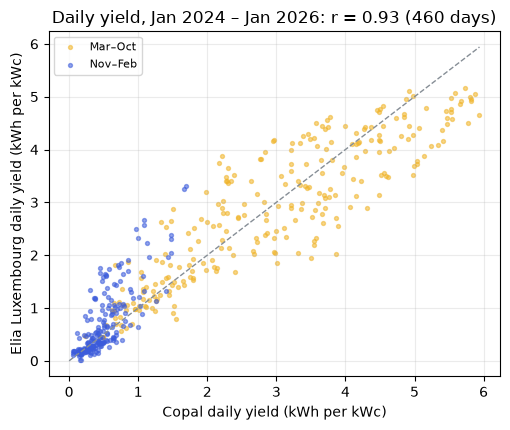

clear-day PV centroid vs clear-sky centroid (21 clear days): Copal +1.9 min, Elia +0.4 min, difference -1.5 min


In [3]:
def solar_geometry(times: pd.DatetimeIndex) -> tuple[np.ndarray, np.ndarray]:
    # NOAA solar zenith (degrees) and extraterrestrial normal irradiance (W/m²) at UTC `times`.
    year_start = pd.to_datetime(times.year.astype(str) + "-01-01", utc=True)
    doy = np.asarray((times - year_start).total_seconds() / 86400.0)  # fractional, 0-based
    year_len = np.where(times.is_leap_year, 366.0, 365.0)
    g = 2.0 * np.pi / year_len * doy
    eqtime = 229.18 * (0.000075 + 0.001868 * np.cos(g) - 0.032077 * np.sin(g)
                       - 0.014615 * np.cos(2 * g) - 0.040849 * np.sin(2 * g))
    decl = (0.006918 - 0.399912 * np.cos(g) + 0.070257 * np.sin(g) - 0.006758 * np.cos(2 * g)
            + 0.000907 * np.sin(2 * g) - 0.002697 * np.cos(3 * g) + 0.00148 * np.sin(3 * g))
    minutes = np.asarray(times.hour * 60.0 + times.minute + times.second / 60.0)
    hour_angle = np.radians(((minutes + (eqtime + 4.0 * LONGITUDE)) % 1440.0) / 4.0 - 180.0)
    lat = np.radians(LATITUDE)
    cos_z = np.clip(np.sin(lat) * np.sin(decl) + np.cos(lat) * np.cos(decl) * np.cos(hour_angle), -1.0, 1.0)
    zenith = np.degrees(np.arccos(cos_z))
    dni_extra = 1361.0 * (1.0 + 0.033 * np.cos(2.0 * np.pi * doy / year_len))
    return zenith, dni_extra


def clear_sky_ghi(times: pd.DatetimeIndex, linke_turbidity: float = 3.0) -> tuple[np.ndarray, np.ndarray]:
    # Ineichen–Perez clear-sky GHI (W/m², sea level) and cos(zenith) at the midpoint of each interval.
    zenith, dni_extra = solar_geometry(times + SLOT / 2)
    cos_z = np.cos(np.radians(zenith))
    up = zenith < 90.0
    z = np.where(up, zenith, 0.0)
    airmass = 1.0 / (np.cos(np.radians(z)) + 0.50572 * (96.07995 - z) ** -1.6364)  # Kasten–Young
    ghi = 0.868 * dni_extra * np.maximum(cos_z, 1e-6) * np.exp(-0.0387 * airmass * linke_turbidity)
    return np.where(up, np.maximum(ghi, 0.0), 0.0), cos_z


def fit_envelope(pv: pd.Series, until: pd.Timestamp) -> dict:
    # The original §3 estimator, restricted to observations strictly before `until`.
    usable = pv.dropna()
    usable = usable[usable.index < until]
    cs = pd.Series(clear_sky_ghi(usable.index)[0], index=usable.index)
    lit = cs >= ENVELOPE_MIN_GHI_WM2
    slope = min(float(np.quantile((usable[lit] / cs[lit]).to_numpy(), ENVELOPE_QUANTILE)), CAPACITY_KWC / 1000)
    cap = min(float(np.quantile(usable.to_numpy(), 0.999)), CAPACITY_KWC)
    return {"kw_per_wm2": round(slope, 6), "max_kw": round(cap, 3), "n_slots": int(lit.sum())}


def make_grid(pv: pd.Series, env: dict) -> pd.DataFrame:
    # One row per 15-min slot, from the first observation to one day past the last (the longest lead).
    grid = pd.DataFrame(index=pd.date_range(pv.index[0], pv.index[-1] + pd.Timedelta(days=1), freq=SLOT))
    grid["cs_ghi"], grid["cos_z"] = clear_sky_ghi(grid.index)
    grid["pv"] = pv.dropna().reindex(grid.index)
    grid["cs_kw"] = (env["kw_per_wm2"] * grid.cs_ghi).clip(0.0, env["max_kw"])
    ok = (grid.cs_ghi >= NIGHT_GHI_WM2) & (grid.cs_kw >= ENV_FLOOR_KW)
    grid["kcs"] = (grid.pv / grid.cs_kw.where(ok)).clip(0.0, KCS_MAX).where(ok & grid.pv.notna())
    return grid


ELIA_ENV = fit_envelope(elia_pv, TRAIN_END)
env_table = pd.DataFrame({
    "Copal plant (shipped, model_config.json)": {"kW per W/m² clear-sky GHI": COPAL_ENV["kw_per_wm2"], "cap (kW)": COPAL_ENV["max_kw"],
                                              "cap ÷ 973.81 kWc": round(COPAL_ENV["max_kw"] / CAPACITY_KWC, 3)},
    "Elia Luxembourg (refitted, before cut-off)": {"kW per W/m² clear-sky GHI": ELIA_ENV["kw_per_wm2"], "cap (kW)": ELIA_ENV["max_kw"],
                                                    "cap ÷ 973.81 kWc": round(ELIA_ENV["max_kw"] / CAPACITY_KWC, 3)},
})
display(env_table)
if ELIA_ENV["kw_per_wm2"] >= CAPACITY_KWC / 1000 - 1e-6:
    print("note: the Elia slope sits at the estimator's ceiling (1 kW per kWc per 1000 W/m²): at low sun the province produces "
          "more per W/m² of clear-sky GHI than a nameplate allows, so its 99.5th percentile is never reached — see §8.")

elia_grid, copal_grid = make_grid(elia_pv, ELIA_ENV), make_grid(copal_pv, COPAL_ENV)

# Does the regional series track the plant? Daily energy on days where both series are complete.
both = pd.concat([copal_pv.rename("copal"), elia_pv.rename("elia")], axis=1).dropna()
days = both.groupby(both.index.floor("D")).agg(n=("copal", "size"), copal=("copal", "sum"), elia=("elia", "sum"))
days = days[days.n == 96] * [1, 0.25 / CAPACITY_KWC, 0.25 / CAPACITY_KWC]          # kWh/kWc per day
r_daily = float(days.copal.corr(days.elia))
winter = days.index.month.isin([11, 12, 1, 2])
fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.scatter(days.copal[~winter], days.elia[~winter], s=8, alpha=0.55, color="#f0b429", label="Mar–Oct")
ax.scatter(days.copal[winter], days.elia[winter], s=8, alpha=0.55, color="#3b5bdb", label="Nov–Feb")
ax.plot([0, days.copal.max()], [0, days.copal.max()], color="#868e96", lw=1, ls="--")
ax.set_xlabel("Copal daily yield (kWh per kWc)")
ax.set_ylabel("Elia Luxembourg daily yield (kWh per kWc)")
ax.set_title(f"Daily yield, {days.index[0]:%b %Y} – {days.index[-1]:%b %Y}: r = {r_daily:.2f} ({len(days)} days)")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

# Time-stamp convention: on clear days the PV centroid should sit at the same time of day for both
# sources, up to the orientation of the plant(s). A 15–30 min convention mismatch would show up here.
def day_kcs(pv: pd.Series, env: dict) -> pd.Series:
    cs = pd.Series(clear_sky_ghi(pv.index)[0], index=pv.index) * env["kw_per_wm2"]
    d = pd.DataFrame({"pv": pv, "cs": cs}).groupby(pv.index.floor("D")).sum()
    return d.pv / d.cs


def centroid_offset_min(pv: pd.Series, day_index: pd.DatetimeIndex) -> pd.Series:
    # Minutes by which the PV energy centroid trails the clear-sky centroid, per day (slot midpoints).
    d = pd.DataFrame({"pv": pv.dropna()})
    d = d[d.index.floor("D").isin(day_index)]
    d["cs"] = clear_sky_ghi(d.index)[0]
    t = d.index.hour * 60 + d.index.minute + 7.5
    g = pd.DataFrame({"pv": d.pv, "cs": d.cs, "pv_t": d.pv * t, "cs_t": d.cs * t}).groupby(d.index.floor("D")).sum()
    return g.pv_t / g.pv - g.cs_t / g.cs


k_copal, k_elia = day_kcs(copal_pv.dropna(), COPAL_ENV).reindex(days.index), day_kcs(elia_pv.dropna(), ELIA_ENV).reindex(days.index)
clear_days = days.index[(k_copal >= k_copal.quantile(0.85)) & (k_elia >= k_elia.quantile(0.85))]
off_copal, off_elia = centroid_offset_min(copal_pv, clear_days).median(), centroid_offset_min(elia_pv, clear_days).median()
print(f"clear-day PV centroid vs clear-sky centroid ({len(clear_days)} clear days): Copal {off_copal:+.1f} min, "
      f"Elia {off_elia:+.1f} min, difference {off_elia - off_copal:+.1f} min")
assert abs(off_elia - off_copal) < 10, "time-stamp conventions look inconsistent"

## 4 · Features, scoring, and the gate

The shipped feature builder and quantile post-processing, with the data frame (`grid`) and the weather slot
table passed in as arguments instead of read from globals. Weather features follow the package's own rule:
previous-run forecasts, `d1` (issued 24 h before the valid time) when its run is usable at the issue time,
`d2` (48 h) otherwise. Persistence is the same slot 24 h earlier.

**The gate.** Before any Elia number is believed, the packaged models run on the Copal hold-out and must
reproduce the current release's figures published in `metrics.json`. This also checks that the package on
disk is the one those metrics describe.


In [4]:
def nwp_slot_features(index: pd.DatetimeIndex) -> pd.DataFrame:
    # Hourly weather → 15-min slots, for each lead offset k (d1 / d2). Radiation = mean of the preceding hour, so a
    # slot takes the hour that contains it; instantaneous variables are interpolated to the slot midpoint.
    label = index.floor("h") + pd.Timedelta(hours=1)
    mid = index + SLOT / 2
    h0 = mid.floor("h")
    w = ((mid - h0) / pd.Timedelta(hours=1)).to_numpy()
    slots_idx = pd.date_range(index.floor("h").min(), index.floor("h").max() + pd.Timedelta(hours=1), freq=SLOT)
    cs_slots = pd.Series(clear_sky_ghi(slots_idx)[0], index=slots_idx)
    cs = cs_slots.groupby(cs_slots.index.floor("h") + pd.Timedelta(hours=1)).mean().reindex(label).to_numpy()
    out = {}
    for k in NWP_LEADS:
        for var in ("ghi", "dni", "dhi"):
            out[f"{var}_k{k}"] = nwp[f"icon_eu|{var}|d{k}"].reindex(label).to_numpy()
        for var in ("cloud", "temp", "wind"):
            s = nwp[f"icon_eu|{var}|d{k}"]
            out[f"{var}_k{k}"] = (1 - w) * s.reindex(h0).to_numpy() + w * s.reindex(h0 + pd.Timedelta(hours=1)).to_numpy()
        for tag, model in (("icon", "icon_eu"), ("ecmwf", "ecmwf_ifs025"), ("arpege", "meteofrance_arpege_europe")):
            ghi = nwp[f"{model}|ghi|d{k}"].reindex(label).to_numpy()
            out[f"kcs_{tag}_k{k}"] = np.where(cs >= NIGHT_GHI_WM2, np.clip(ghi / np.maximum(cs, 1e-6), 0.0, 1.5), np.nan)
        stack = np.vstack([out[f"kcs_{t}_k{k}"] for t in ("icon", "ecmwf", "arpege")])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            out[f"kcs_ens_k{k}"] = np.where((~np.isnan(stack)).sum(axis=0) >= 2, np.nanmean(stack, axis=0), np.nan)
    return pd.DataFrame(out, index=index)


NWP_SOURCES = {"ghi_fc_wm2": "ghi", "dni_fc_wm2": "dni", "dhi_fc_wm2": "dhi", "cloud_fc_pct": "cloud",
               "temp_fc_c": "temp", "wind_fc_ms": "wind", "kcs_fc": "kcs_icon", "kcs_fc_ens": "kcs_ens"}


def issue_times(block: str, start: pd.Timestamp, end: pd.Timestamp, first: pd.Timestamp) -> pd.DatetimeIndex:
    # Issue schedule of `block` with start <= issue < end (issues without any prior history are dropped).
    days = pd.date_range(start.floor("D"), end, freq="D")
    issues = pd.DatetimeIndex(sorted(d + pd.Timedelta(hours=h) for d in days for h in BLOCKS[block]["issue_hours_utc"]))
    return issues[(issues >= start) & (issues < end) & (issues > first)]


def issue_context(block: str, issues: pd.DatetimeIndex, grid: pd.DataFrame) -> pd.DataFrame:
    # Issue-time features: recent clear-sky index and the last observation (intraday only).
    ctx = pd.DataFrame(index=issues)
    if block == "intraday":
        ctx["kcs_recent"] = grid.kcs.rolling("3h", closed="left").mean().reindex(issues).to_numpy()
        prev1 = grid.pv.reindex(issues - SLOT).to_numpy()
        prev2 = grid.pv.reindex(issues - 2 * SLOT).to_numpy()
        kcs1 = grid.kcs.reindex(issues - SLOT).to_numpy()
        kcs2 = grid.kcs.reindex(issues - 2 * SLOT).to_numpy()
        # the last observation counts only if it is at most 30 min before the issue time
        ctx["pv_last_kw"] = np.where(~np.isnan(prev1), prev1, prev2)
        ctx["kcs_last"] = np.where(~np.isnan(prev1), kcs1, np.where(~np.isnan(prev2), kcs2, np.nan))
    else:
        daily_kcs = grid.kcs.groupby(grid.index.floor("D")).mean()
        ctx["kcs_recent"] = daily_kcs.reindex(issues.floor("D") - pd.Timedelta(days=1)).to_numpy()
        ctx["pv_last_kw"] = np.nan
        ctx["kcs_last"] = np.nan
    return ctx


def build_samples(block: str, start: pd.Timestamp, end: pd.Timestamp, grid: pd.DataFrame, slots: pd.DataFrame) -> pd.DataFrame:
    # Feature rows, targets and the persistence baseline for every scored slot of every issue in [start, end).
    issues = issue_times(block, start, end, grid.pv.first_valid_index())
    ctx = issue_context(block, issues, grid)
    lo, hi = (int(h * 4) for h in BLOCKS[block]["leads_h"])
    leads = np.arange(lo, hi)
    issue_ns = np.repeat(issues.as_unit("ns").asi8, len(leads))     # .asi8 follows the index unit, so force ns
    k = np.tile(leads, len(issues))
    ts = pd.DatetimeIndex(pd.to_datetime(issue_ns + k * SLOT.value, unit="ns", utc=True))
    issue = pd.DatetimeIndex(pd.to_datetime(issue_ns, unit="ns", utc=True))

    at = grid.reindex(ts)
    lag_ts = ts - pd.Timedelta(hours=24)
    lag = grid.reindex(lag_ts)
    keep = at.pv.notna().to_numpy() & (at.cs_ghi >= NIGHT_GHI_WM2).to_numpy() & lag.pv.notna().to_numpy()
    ts, issue, k, at, lag, lag_ts = ts[keep], issue[keep], k[keep], at[keep], lag[keep], lag_ts[keep]

    pv_lag = np.where(lag_ts < issue, lag.pv.to_numpy(), np.nan)          # always available: lead < 24 h
    kcs_lag = np.where(np.isnan(pv_lag), np.nan, lag.kcs.to_numpy())
    c = ctx.reindex(issue)
    lead_h = k * 0.25

    # weather: d1 when its run is usable at the issue time, else d2; fall back to d2 if d1 is missing
    nw = slots.reindex(ts)
    want_d1 = lead_h <= 24.0 - NWP_LAG_H
    have_d1 = ~np.isnan(nw["ghi_k1"].to_numpy()) & ~np.isnan(nw["cloud_k1"].to_numpy())
    have_d2 = ~np.isnan(nw["ghi_k2"].to_numpy()) & ~np.isnan(nw["cloud_k2"].to_numpy())
    use_d1 = want_d1 & have_d1
    has_w = use_d1 | have_d2

    def pick(name: str) -> np.ndarray:
        v = np.where(use_d1, nw[f"{name}_k1"].to_numpy(), nw[f"{name}_k2"].to_numpy())
        return np.where(has_w & ~np.isnan(v), v, MISSING)

    minutes = ts.hour * 60 + ts.minute
    tod = 2 * np.pi * minutes / 1440.0
    doy = 2 * np.pi * (ts.dayofyear - 1) / 365.25
    f = pd.DataFrame(
        {
            "clear_sky_kw": at.cs_kw.to_numpy(),
            "clear_sky_ghi_wm2": at.cs_ghi.to_numpy(),
            "cos_zenith": np.maximum(at.cos_z.to_numpy(), 0.0),
            "tod_sin": np.sin(tod), "tod_cos": np.cos(tod),
            "doy_sin": np.sin(doy), "doy_cos": np.cos(doy),
            "lead_time_hours": lead_h,
            "has_recent": c.kcs_recent.notna().astype(float).to_numpy(),
            "kcs_recent": c.kcs_recent.fillna(MISSING).to_numpy(),
            "pv_last_kw": c.pv_last_kw.fillna(MISSING).to_numpy(),
            "kcs_last": c.kcs_last.fillna(MISSING).to_numpy(),
            "pv_lag_24h_kw": np.nan_to_num(pv_lag, nan=MISSING),
            "kcs_lag_24h": np.nan_to_num(kcs_lag, nan=MISSING),
            "has_weather": has_w.astype(float),
            **{feat: pick(src) for feat, src in NWP_SOURCES.items()},
            "nwp_lead_d": np.where(has_w, np.where(use_d1, 1.0, 2.0), MISSING),
        }
    )
    trainable = (at.cs_kw >= ENV_FLOOR_KW).to_numpy()
    f["target_kcs"] = np.where(trainable, np.clip(at.pv.to_numpy() / np.maximum(at.cs_kw.to_numpy(), 1e-9), 0.0, KCS_MAX), np.nan)
    f["actual_kw"] = at.pv.to_numpy()
    f["pers_kw"] = pv_lag
    f["issue"] = issue
    f["ts"] = ts
    return f


def forecast(block: str, samples: pd.DataFrame, cap_kw: float) -> pd.DataFrame:
    # The packaged boosters → P10/P50/P90 (raw) and P10c/P90c (shipped frozen conformal offsets) in kW.
    X = samples[FEATURE_NAMES]
    q = np.sort(np.clip(np.vstack([BOOSTERS[block][k].predict(X) for k in ("q10", "q50", "q90")]), 0.0, KCS_MAX), axis=0)
    lo, hi = q[0].copy(), q[2].copy()
    if CONFIG["conformal"]["enabled"]:
        lead = X["lead_time_hours"].to_numpy()
        for o in BLOCKS[block]["band_offsets"]:
            m = (lead >= o["lead_from_h"]) & (lead < o["lead_to_h"])
            lo[m], hi[m] = lo[m] - o["lower"], hi[m] + o["upper"]
        lo, hi = np.clip(np.minimum(lo, q[1]), 0.0, KCS_MAX), np.clip(np.maximum(hi, q[1]), 0.0, KCS_MAX)
    cs = samples.clear_sky_kw.to_numpy()
    kcs_recent = samples.kcs_recent.to_numpy()
    recent = np.where(kcs_recent != MISSING, np.minimum(1.0, kcs_recent), 0.5)
    out = samples[["issue", "ts"]].reset_index(drop=True)
    out.insert(0, "block", block)
    return out.assign(lead_h=samples.lead_time_hours.to_numpy(), actual=samples.actual_kw.to_numpy(), clear_sky=cs,
                      p10=np.minimum(q[0] * cs, cap_kw), p50=np.minimum(q[1] * cs, cap_kw), p90=np.minimum(q[2] * cs, cap_kw),
                      p10c=np.minimum(lo * cs, cap_kw), p90c=np.minimum(hi * cs, cap_kw),
                      pers=samples.pers_kw.to_numpy(), cs_pers=np.minimum(recent * cs, cap_kw))


def scores(actual: np.ndarray, p10: np.ndarray, p50: np.ndarray, p90: np.ndarray, pers: np.ndarray) -> dict:
    err = p50 - actual
    mae, mae_p = float(np.mean(np.abs(err))), float(np.mean(np.abs(pers - actual)))
    return {
        "n": len(actual),
        "mae_kw": round(mae, 3),
        "rmse_kw": round(float(np.sqrt(np.mean(err ** 2))), 3),
        "bias_kw": round(float(np.mean(err)), 3),
        "nmae_capacity_pct": round(100 * mae / CAPACITY_KWC, 3),
        "r2": round(1 - float(np.sum(err ** 2)) / float(np.sum((actual - actual.mean()) ** 2)), 3),
        "coverage_p10_p90_pct": round(100 * float(np.mean((p10 <= actual) & (actual <= p90))), 1),
        "persistence_mae_kw": round(mae_p, 3),
        "skill_vs_persistence_pct": round(100 * (1 - mae / mae_p), 2),
    }


def report(g: pd.DataFrame) -> dict:
    s = scores(g.actual.to_numpy(), g.p10.to_numpy(), g.p50.to_numpy(), g.p90.to_numpy(), g.pers.to_numpy())
    s["clear_sky_persistence_mae_kw"] = round(float(np.mean(np.abs(g.cs_pers - g.actual))), 3)
    return s


HORIZONS = ["< 1 h", "1–6 h", "day-ahead (6–24 h)"]
COLUMNS = {"n": "slots", "mae_kw": "MAE (kW)", "nmae_capacity_pct": "nMAE (% of capacity)", "bias_kw": "bias (kW)",
           "rmse_kw": "RMSE (kW)", "r2": "R²", "coverage_p10_p90_pct": "P10–P90 coverage (%)",
           "persistence_mae_kw": "persistence MAE (kW)", "skill_vs_persistence_pct": "skill vs persistence (%)",
           "clear_sky_persistence_mae_kw": "clear-sky persistence MAE (kW)"}


def horizon_of(leads: pd.DataFrame) -> pd.Series:
    return pd.cut(leads.lead_h, [0.0, 1.0, 6.0, 24.0], right=False, labels=HORIZONS)


def tabulate(groups: dict, columns: list) -> pd.DataFrame:
    return pd.DataFrame(groups).T.astype({"n": int})[columns].rename(columns=COLUMNS)


# ---- Gate: the packaged models on the Copal hold-out must reproduce metrics.json -------------------
NWP_SLOTS = nwp_slot_features(pd.date_range(copal_pv.index[0], ELIA_END + pd.Timedelta(days=1), freq=SLOT))
copal_leads = pd.concat([forecast(b, build_samples(b, TRAIN_END, COPAL_LAST, copal_grid, NWP_SLOTS), COPAL_ENV["max_kw"])
                         for b in BLOCKS], ignore_index=True)

published = {r["block"]: r for r in metrics["holdout_vs_previous_release"] if r["model"].startswith("current release")}
gate = pd.DataFrame({
    b: {"slots (published)": published[b]["slots"], "slots (here)": got["n"],
        "nMAE % (published)": published[b]["nMAE (%)"], "nMAE % (here)": got["nmae_capacity_pct"],
        "skill % (published)": published[b]["skill vs persistence (%)"], "skill % (here)": got["skill_vs_persistence_pct"],
        "coverage % (published)": published[b]["coverage raw (%)"], "coverage % (here)": got["coverage_p10_p90_pct"],
        "bias kW (published)": published[b]["bias (kW)"], "bias kW (here)": got["bias_kw"]}
    for b, got in ((b, report(copal_leads[copal_leads.block == b])) for b in BLOCKS)
}).T
display(gate)
assert all(int(gate.loc[b, "slots (here)"]) == published[b]["slots"] for b in BLOCKS), "gate: slot counts differ from metrics.json"
worst = max(abs(gate.loc[b, "nMAE % (here)"] - published[b]["nMAE (%)"]) for b in BLOCKS)
assert worst < 0.02, f"gate failed: nMAE differs from metrics.json by up to {worst:.3f} points"
print(f"gate passed — the packaged models reproduce the published Copal hold-out (largest nMAE difference {worst:.3f} points)")


,slots (published),slots (here),nMAE % (published),nMAE % (here),skill % (published),skill % (here),coverage % (published),coverage % (here),bias kW (published),bias kW (here)
intraday,5265.0,5265.0,1.69,1.686,33.75,33.75,69.74,69.7,2.46,2.462
day_ahead,5253.0,5253.0,1.74,1.739,31.10,31.10,70.32,70.3,1.07,1.067


gate passed — the packaged models reproduce the published Copal hold-out (largest nMAE difference 0.004 points)


## 5 · Elia samples and forecasts

Forecasts are issued on the original schedule (intraday every 2 h from 04 to 18 UTC; day-ahead at 00 / 06 /
12 / 18 UTC) for every issue time from the training cut-off to the end of September. Features use only
observations strictly before each issue time — the shipped leakage rule, now applied to the Elia series.

In [5]:
def run_scenario(env: dict) -> pd.DataFrame:
    grid = make_grid(elia_pv, env)
    parts = [forecast(b, build_samples(b, TRAIN_END, ELIA_END, grid, NWP_SLOTS), env["max_kw"]) for b in BLOCKS]
    leads = pd.concat(parts, ignore_index=True)
    leads["window"] = np.where(leads.issue < COPAL_LAST, WINDOWS[0], WINDOWS[1])
    leads["horizon"] = horizon_of(leads)
    leads["month"] = leads.ts.dt.strftime("%Y-%m")
    return leads


leads = run_scenario(ELIA_ENV)                 # primary: envelope refitted on Elia, before the cut-off
leads_copal_env = run_scenario(COPAL_ENV)      # sensitivity: Copal's envelope as-is (§9)

display(leads.groupby(["window", "block"]).agg(slots=("actual", "size"), issues=("issue", "nunique"),
                                               first_target=("ts", "min"), last_target=("ts", "max")))


slots  issues  \
window                                      block                      
hold-out window (19 Nov 2025 → 18 Jan 2026) day_ahead   5302     240   
                                            intraday    5265     360   
new period (19 Jan → 30 Sep 2026)           day_ahead  38864    1018   
                                            intraday   35139    1897   

                                                                   first_target  \
window                                      block                                 
hold-out window (19 Nov 2025 → 18 Jan 2026) day_ahead 2025-11-20 07:15:00+00:00   
                                            intraday  2025-11-20 07:15:00+00:00   
new period (19 Jan → 30 Sep 2026)           day_ahead 2026-01-19 07:45:00+00:00   
                                            intraday  2026-01-19 07:45:00+00:00   

                                                                    last_target  
window                                      block                                
hold-out window (19 Nov 2025 → 18 Jan 2026) day_ahead 2026-01-19 15:30:00+00:00  
                                            intraday  2026-01-18 15:15:00+00:00  
new period (19 Jan → 30 Sep 2026)           day_ahead 2026-09-30 16:45:00+00:00  
                                            intraday  2026-09-30 16:45:00+00:00

## 6 · Results

Daytime 15-minute slots, scored as in the shipped pipeline. nMAE is a percentage of capacity, so it can
be set beside the Copal figures; kW values are Copal-equivalent kW. The reference rows are the gate's
Copal hold-out (one plant, winter) and Elia's series over the same 60 days (a province, same sky), then the new
period. Differences between the first two rows are the **transfer effect**; between the last two, the
**season effect**.

In [6]:
CMP = ["n", "mae_kw", "nmae_capacity_pct", "bias_kw", "r2", "coverage_p10_p90_pct", "persistence_mae_kw", "skill_vs_persistence_pct"]

by_block = {}
for window in WINDOWS:
    for block in BLOCKS:
        by_block[(window, block)] = report(leads[(leads.window == window) & (leads.block == block)])
for block in BLOCKS:
    by_block[("whole test window", block)] = report(leads[leads.block == block])
table = tabulate(by_block, CMP + ["clear_sky_persistence_mae_kw"])
table.index = pd.MultiIndex.from_tuples(table.index, names=["window", "block"])
display(Markdown("**By block**"))
display(table)

by_horizon = {(f"Copal plant — hold-out (winter, gate)", str(h)): report(g) for h, g in copal_leads.groupby(horizon_of(copal_leads), observed=True)}
for window in WINDOWS:
    for h in HORIZONS:
        by_horizon[(f"Elia — {window}", h)] = report(leads[(leads.window == window) & (leads.horizon == h)])
horizon_table = tabulate(by_horizon, CMP)
horizon_table.index = pd.MultiIndex.from_tuples(horizon_table.index, names=["source and window", "horizon"])
display(Markdown("**By forecast horizon** (the service specification's three buckets)"))
display(horizon_table)

**By block**

slots  MAE (kW)  \
window                                      block                        
hold-out window (19 Nov 2025 → 18 Jan 2026) intraday    5265    33.430   
                                            day_ahead   5302    36.581   
new period (19 Jan → 30 Sep 2026)           intraday   35139    48.018   
                                            day_ahead  38864    50.633   
whole test window                           intraday   40404    46.117   
                                            day_ahead  44166    48.946   

                                                       nMAE (% of capacity)  \
window                                      block                             
hold-out window (19 Nov 2025 → 18 Jan 2026) intraday                  3.433   
                                            day_ahead                 3.756   
new period (19 Jan → 30 Sep 2026)           intraday                  4.931   
                                            day_ahead                 5.200   
whole test window                           intraday                  4.736   
                                            day_ahead                 5.026   

                                                       bias (kW)     R²  \
window                                      block                         
hold-out window (19 Nov 2025 → 18 Jan 2026) intraday     -12.180  0.553   
                                            day_ahead    -11.291  0.493   
new period (19 Jan → 30 Sep 2026)           intraday      18.658  0.843   
                                            day_ahead     23.437  0.822   
whole test window                           intraday      14.640  0.854   
                                            day_ahead     19.268  0.831   

                                                       P10–P90 coverage (%)  \
window                                      block                             
hold-out window (19 Nov 2025 → 18 Jan 2026) intraday                   53.6   
                                            day_ahead                  50.3   
new period (19 Jan → 30 Sep 2026)           intraday                   70.6   
                                            day_ahead                  70.6   
whole test window                           intraday                   68.4   
                                            day_ahead                  68.2   

                                                       persistence MAE (kW)  \
window                                      block                             
hold-out window (19 Nov 2025 → 18 Jan 2026) intraday                 49.007   
                                            day_ahead                49.248   
new period (19 Jan → 30 Sep 2026)           intraday                 73.282   
                                            day_ahead                68.755   
whole test window                           intraday                 70.119   
                                            day_ahead                66.413   

                                                       skill vs persistence (%)  \
window                                      block                                 
hold-out window (19 Nov 2025 → 18 Jan 2026) intraday                      31.79   
                                            day_ahead                     25.72   
new period (19 Jan → 30 Sep 2026)           intraday                      34.48   
                                            day_ahead                     26.36   
whole test window                           intraday                      34.23   
                                            day_ahead                     26.30   

                                                       clear-sky persistence MAE (kW)  
window                                      block                                      
hold-out window (19 Nov 2025 → 18 Jan 2026) intraday                           38.067  
                                 

**By forecast horizon** (the service specification's three buckets)

slots  \
source and window                                  horizon                     
Copal plant — hold-out (winter, gate)              < 1 h                 960   
                                                   1–6 h                4305   
                                                   day-ahead (6–24 h)   5253   
Elia — hold-out window (19 Nov 2025 → 18 Jan 2026) < 1 h                 960   
                                                   1–6 h                4305   
                                                   day-ahead (6–24 h)   5302   
Elia — new period (19 Jan → 30 Sep 2026)           < 1 h                6559   
                                                   1–6 h               28580   
                                                   day-ahead (6–24 h)  38864   

                                                                       MAE (kW)  \
source and window                                  horizon                        
Copal plant — hold-out (winter, gate)              < 1 h                 13.616   
                                                   1–6 h                 17.041   
                                                   day-ahead (6–24 h)    16.932   
Elia — hold-out window (19 Nov 2025 → 18 Jan 2026) < 1 h                 25.256   
                                                   1–6 h                 35.253   
                                                   day-ahead (6–24 h)    36.581   
Elia — new period (19 Jan → 30 Sep 2026)           < 1 h                 40.604   
                                                   1–6 h                 49.719   
                                                   day-ahead (6–24 h)    50.633   

                                                                       nMAE (% of capacity)  \
source and window                                  horizon                                    
Copal plant — hold-out (winter, gate)              < 1 h                              1.398   
                                                   1–6 h                              1.750   
                                                   day-ahead (6–24 h)                 1.739   
Elia — hold-out window (19 Nov 2025 → 18 Jan 2026) < 1 h                              2.593   
                                                   1–6 h                              3.620   
                                                   day-ahead (6–24 h)                 3.756   
Elia — new period (19 Jan → 30 Sep 2026)           < 1 h                              4.170   
                                                   1–6 h                              5.106   
                                                   day-ahead (6–24 h)                 5.200   

                                                                       bias (kW)  \
source and window                                  horizon                         
Copal plant — hold-out (winter, gate)              < 1 h                   0.958   
                                                   1–6 h                   2.797   
                                                   day-ahead (6–24 h)      1.067   
Elia — hold-out window (19 Nov 2025 → 18 Jan 2026) < 1 h                 -10.875   
                                                   1–6 h                 -12.471   
                                                   day-ahead (6–24 h)    -11.291   
Elia — new period (19 Jan → 30 Sep 2026)           < 1 h                  18.116   
                                                   1–6 h                  18.782   
                                                   day-ahead (6–24 h)     23.437   

                                                                          R²  \
source and window                                  horizon                     
Copal plant — hold-out (winter, gate)              < 1 h               0.703   
                                                   1–6 h         

### Skill by lead time

Each lead hour mixes different times of day (issues every 2 h / 6 h), so raw MAE mostly tracks how much sun
those slots get; skill compares the model and persistence on the same slots.

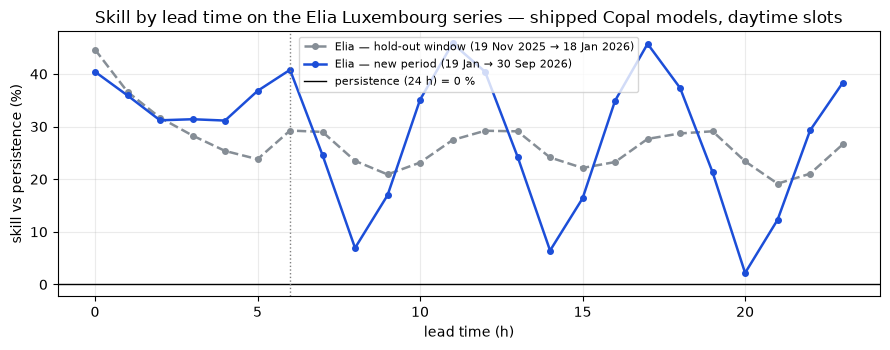

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.6))
styles = {WINDOWS[0]: ("#868e96", "--"), WINDOWS[1]: ("#1c4ed8", "-")}
for window, (color, ls) in styles.items():
    sub = leads[leads.window == window]
    by_hour = (sub.assign(hour=np.floor(sub.lead_h), model=(sub.p50 - sub.actual).abs(),
                          persistence=(sub.pers - sub.actual).abs())
               .groupby("hour")[["model", "persistence"]].mean())
    skill = 100 * (1 - by_hour.model / by_hour.persistence)
    ax.plot(skill.index, skill, marker="o", ms=4, lw=1.8, ls=ls, color=color, label=f"Elia — {window}")
ax.axhline(0, color="black", lw=1, label="persistence (24 h) = 0 %")
ax.axvline(6, ls=":", color="grey", lw=1)
ax.set_xlabel("lead time (h)")
ax.set_ylabel("skill vs persistence (%)")
ax.set_title("Skill by lead time on the Elia Luxembourg series — shipped Copal models, daytime slots")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 7 · Season by season

The point of the extra months: the Copal hold-out saw only winter days (low sun, low yield, so small
absolute errors). Per target month, per block. The mean capacity factor is the average actual output of the
daylight slots as a % of capacity — nMAE should be read next to it.

slots  mean output (% of capacity)  MAE (kW)  \
month   block                                                     
2025-11 day_ahead    978                          6.7    28.807   
        intraday    1005                          6.6    26.043   
2025-12 day_ahead   2673                          9.2    41.096   
        intraday    2660                          9.2    38.539   
2026-01 day_ahead   2871                          6.2    33.274   
        intraday    2854                          6.2    28.768   
2026-02 day_ahead   3111                         11.1    41.514   
        intraday    3018                         11.4    36.975   
2026-03 day_ahead   4125                         24.4    42.267   
        intraday    3893                         25.4    40.707   
2026-04 day_ahead   4659                         29.4    44.834   
        intraday    4205                         31.3    41.908   
2026-05 day_ahead   5394                         23.4    50.054   
        intraday    4714                         25.4    48.963   
2026-06 day_ahead   5475                         25.2    56.561   
        intraday    4755                         27.5    56.454   
2026-07 day_ahead   5556                         27.0    67.096   
        intraday    4860                         29.4    64.368   
2026-08 day_ahead   5052                         24.2    56.533   
        intraday    4516                         26.0    54.833   
2026-09 day_ahead   4272                         25.1    41.614   
        intraday    3924                         26.5    37.341   

                   nMAE (% of capacity)  bias (kW)  P10–P90 coverage (%)  \
month   block                                                              
2025-11 day_ahead                 2.958     -2.387                  71.9   
        intraday                  2.674     -3.187                  73.3   
2025-12 day_ahead                 4.220    -24.377                  50.7   
        intraday                  3.958    -26.054                  53.5   
2026-01 day_ahead                 3.417      2.558                  47.8   
        intraday                  2.954      0.803                  53.4   
2026-02 day_ahead                 4.263     -2.189                  71.8   
        intraday                  3.797     -6.519                  71.8   
2026-03 day_ahead                 4.340    -11.826                  61.3   
        intraday                  4.180    -17.594                  61.1   
2026-04 day_ahead                 4.604    -11.152                  64.2   
        intraday                  4.304     -6.741                  60.8   
2026-05 day_ahead                 5.140     36.782                  79.6   
        intraday                  5.028     32.785                  76.7   
2026-06 day_ahead                 5.808     40.995                  76.9   
        intraday                  5.797     35.000                  78.2   
2026-07 day_ahead                 6.890     58.028                  65.4   
        intraday                  6.610     52.541                  67.2   
2026-08 day_ahead                 5.805     45.171                  69.7   
        intraday                  5.631     42.406                  69.5   
2026-09 day_ahead                 4.273     10.590                  76.3   
        intraday                  3.835      2.652                  79.2   

                   persistence MAE (kW)  skill vs persistence (%)  
month   block                                                      
2025-11 day_ahead                46.340                     37.84  
        intraday                 45.512                     42.78  
2025-12 day_ahead                61.059                     32.69  
        intraday                 61.314                     37.14  
2026-01 day_ahead                32.952                     -0.98  
        intraday                 33.104                     13.10  
2026-02 day_ahead                65.190  

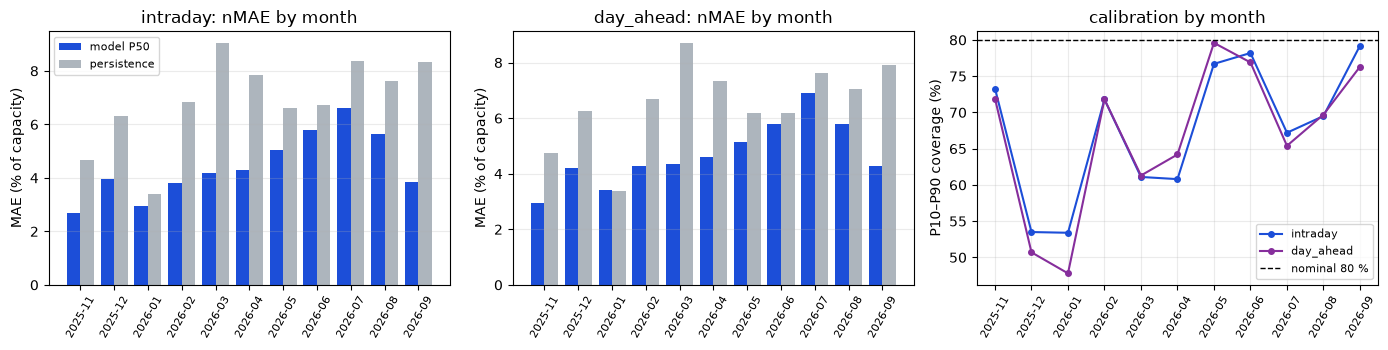

**By meteorological season** (target month; autumn = late Nov 2025 and Sep 2026)

slots  MAE (kW)  nMAE (% of capacity)  bias (kW)     R²  \
season block                                                                
winter day_ahead   8655    38.652                 3.969     -7.467  0.601   
       intraday    8532    34.718                 3.565    -10.160  0.664   
spring day_ahead  14178    46.073                 4.731      6.889  0.869   
       intraday   12812    44.139                 4.533      4.504  0.883   
summer day_ahead  16083    60.192                 6.181     48.191  0.747   
       intraday   14131    58.657                 6.024     43.399  0.762   
autumn day_ahead   5250    39.229                 4.028      8.173  0.885   
       intraday    4929    35.037                 3.598      1.461  0.912   

                  P10–P90 coverage (%)  persistence MAE (kW)  \
season block                                                   
winter day_ahead                  57.3                53.220   
       intraday                   59.9                53.780   
spring day_ahead                  69.2                71.085   
       intraday                   66.7                75.479   
summer day_ahead                  70.7                67.775   
       intraday                   71.7                73.790   
autumn day_ahead                  75.5                71.370   
       intraday                   78.0                73.941   

                  skill vs persistence (%)  
season block                                
winter day_ahead                     27.37  
       intraday                      35.44  
spring day_ahead                     35.19  
       intraday                      41.52  
summer day_ahead                     11.19  
       intraday                      20.51  
autumn day_ahead                     45.04  
       intraday                      52.61

In [8]:
monthly = {}
for (month, block), g in leads.groupby(["month", "block"]):
    monthly[(month, block)] = {**report(g), "mean_cf_pct": round(100 * float(g.actual.mean()) / CAPACITY_KWC, 1)}
mt = pd.DataFrame(monthly).T.astype({"n": int})
mt.index = pd.MultiIndex.from_tuples(mt.index, names=["month", "block"])
display(mt[["n", "mean_cf_pct", "mae_kw", "nmae_capacity_pct", "bias_kw", "coverage_p10_p90_pct", "persistence_mae_kw",
            "skill_vs_persistence_pct"]].rename(columns={**COLUMNS, "mean_cf_pct": "mean output (% of capacity)"}))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
months = sorted(leads.month.unique())
x = np.arange(len(months))
for ax, block in zip(axes[:2], BLOCKS):
    m = mt.xs(block, level="block").loc[months]
    ax.bar(x - 0.2, m.nmae_capacity_pct, 0.4, color="#1c4ed8", label="model P50")
    ax.bar(x + 0.2, 100 * m.persistence_mae_kw / CAPACITY_KWC, 0.4, color="#adb5bd", label="persistence")
    ax.set_xticks(x, months, rotation=60, fontsize=8)
    ax.set_title(f"{block}: nMAE by month")
    ax.set_ylabel("MAE (% of capacity)")
    ax.grid(alpha=0.25, axis="y")
axes[0].legend(fontsize=8)
for block, color in zip(BLOCKS, ("#1c4ed8", "#862e9c")):
    m = mt.xs(block, level="block").loc[months]
    axes[2].plot(x, m.coverage_p10_p90_pct, marker="o", ms=4, color=color, label=block)
axes[2].axhline(80, color="black", lw=1, ls="--", label="nominal 80 %")
axes[2].set_xticks(x, months, rotation=60, fontsize=8)
axes[2].set_ylabel("P10–P90 coverage (%)")
axes[2].set_title("calibration by month")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.25)
fig.tight_layout()
plt.show()

SEASONS = {12: "winter", 1: "winter", 2: "winter", 3: "spring", 4: "spring", 5: "spring",
           6: "summer", 7: "summer", 8: "summer", 9: "autumn", 10: "autumn", 11: "autumn"}
season = leads.ts.dt.month.map(SEASONS)
seasonal = {(s, b): report(g) for (s, b), g in leads.groupby([season, leads.block])}
st = tabulate(seasonal, CMP)
st.index = pd.MultiIndex.from_tuples(st.index, names=["season", "block"])
display(Markdown("**By meteorological season** (target month; autumn = late Nov 2025 and Sep 2026)"))
display(st.loc[["winter", "spring", "summer", "autumn"]])

## 8 · Why the transfer costs accuracy — the site's clear-sky shape

On the *same* 60 winter days the Elia series is forecast about twice as badly as Copal itself (in % of
capacity), with a large negative bias that turns positive in summer. Skill against persistence, in contrast,
barely moves at short leads. That pattern points at the **shape** of the clear-sky index rather than at the
forecasting skill: the models learned how Copal's output relates to clear-sky irradiance across the year, and
another plant — or a fleet — does not follow that relation.

Two views of the same fact. First, the clear-day relation: the 90th percentile of PV ÷ clear-sky GHI, by
level of clear-sky GHI (before the cut-off, both sources). Second, mean daylight output per calendar month
on the days both sources have in common (same sky), set beside the bias of the day-ahead and intraday
forecasts in the matching test months.

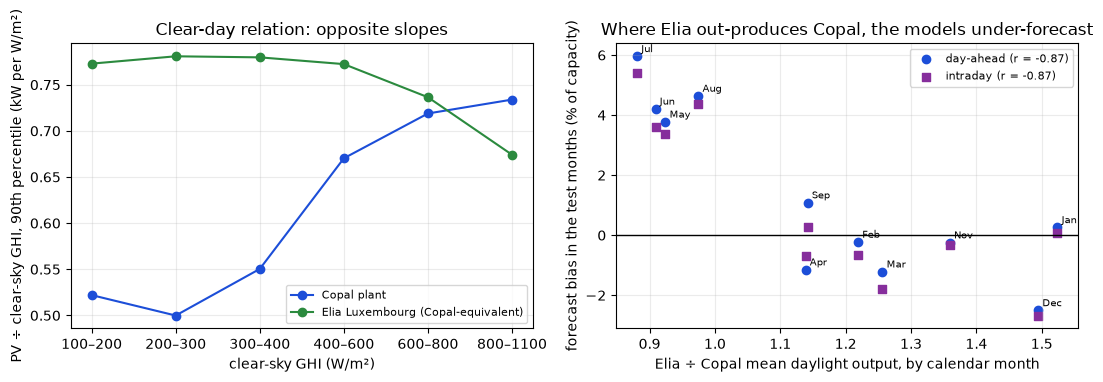

,Copal mean output (% of capacity),Elia mean output (% of capacity),Elia ÷ Copal,day-ahead bias,intraday bias
calendar month,,,,,
7,26.22,23.09,0.88,5.96,5.40
6,26.94,24.49,0.91,4.21,3.59
5,24.50,22.65,0.92,3.78,3.37
8,26.63,25.96,0.97,4.64,4.35
4,20.36,23.18,1.14,-1.15,-0.69
9,18.22,20.80,1.14,1.09,0.27
2,9.91,12.07,1.22,-0.22,-0.67
3,17.05,21.42,1.26,-1.21,-1.81
11,6.35,8.64,1.36,-0.25,-0.33


Pearson r between log(Elia ÷ Copal) and the monthly bias over 11 test months: day-ahead -0.87, intraday -0.87 (descriptive only — weather anomalies add their own bias)


In [9]:
def clear_day_shape(pv: pd.Series) -> pd.Series:
    # 90th percentile of PV / clear-sky GHI per clear-sky-GHI bin, observations before the cut-off.
    u = pv.dropna()
    u = u[u.index < TRAIN_END]
    cs = pd.Series(clear_sky_ghi(u.index)[0], index=u.index)
    bins = pd.cut(cs, [100, 200, 300, 400, 600, 800, 1100])
    return (u / cs).where(cs >= 100).groupby(bins, observed=True).quantile(0.9)


shape = pd.DataFrame({"Copal plant": clear_day_shape(copal_pv), "Elia Luxembourg": clear_day_shape(elia_pv)})
shape.index = [f"{int(i.left)}–{int(i.right)}" for i in shape.index]

ov = pd.concat([copal_pv.rename("copal"), elia_pv.rename("elia")], axis=1).dropna()
ov = ov[clear_sky_ghi(ov.index)[0] >= NIGHT_GHI_WM2]
cal = ov.groupby(ov.index.month)[["copal", "elia"]].mean() / CAPACITY_KWC * 100
cal["ratio"] = cal.elia / cal.copal

bias_pct = mt.bias_kw.unstack("block") / CAPACITY_KWC * 100
bias_pct.index = [int(m[-2:]) for m in bias_pct.index]
diag = cal.join(bias_pct.rename(columns={"day_ahead": "day-ahead bias", "intraday": "intraday bias"}), how="inner").sort_values("ratio")
r_da = float(np.corrcoef(np.log(diag.ratio), diag["day-ahead bias"])[0, 1])
r_id = float(np.corrcoef(np.log(diag.ratio), diag["intraday bias"])[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(shape.index, shape["Copal plant"], marker="o", color="#1c4ed8", label="Copal plant")
axes[0].plot(shape.index, shape["Elia Luxembourg"], marker="o", color="#2b8a3e", label="Elia Luxembourg (Copal-equivalent)")
axes[0].set_xlabel("clear-sky GHI (W/m²)")
axes[0].set_ylabel("PV ÷ clear-sky GHI, 90th percentile (kW per W/m²)")
axes[0].set_title("Clear-day relation: opposite slopes")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)
axes[1].scatter(diag.ratio, diag["day-ahead bias"], color="#1c4ed8", label=f"day-ahead (r = {r_da:+.2f})")
axes[1].scatter(diag.ratio, diag["intraday bias"], color="#862e9c", marker="s", label=f"intraday (r = {r_id:+.2f})")
for month, row in diag.iterrows():
    axes[1].annotate(pd.Timestamp(2026, month, 1).strftime("%b"), (row.ratio, row["day-ahead bias"]), fontsize=7,
                     xytext=(3, 3), textcoords="offset points")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xlabel("Elia ÷ Copal mean daylight output, by calendar month")
axes[1].set_ylabel("forecast bias in the test months (% of capacity)")
axes[1].set_title("Where Elia out-produces Copal, the models under-forecast")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

display(diag.rename(columns={"copal": "Copal mean output (% of capacity)", "elia": "Elia mean output (% of capacity)",
                             "ratio": "Elia ÷ Copal"}).round(2).rename_axis("calendar month"))
print(f"Pearson r between log(Elia ÷ Copal) and the monthly bias over {len(diag)} test months: "
      f"day-ahead {r_da:+.2f}, intraday {r_id:+.2f} (descriptive only — weather anomalies add their own bias)")

## 9 · Against Elia's own day-ahead forecast, and envelope sensitivity

**Reference forecast.** Elia publishes a day-ahead forecast at 6 PM (Belgian local time, 16–17 UTC) on D-1
for every quarter-hour of day D, with P10 / P90, built from weather forecasts. The matching Copal model is
the day-ahead model issued at **18:00 UTC on D-1** — two hours *later* than Elia's cut, so timing does not
favour Elia — scored on the slots both forecasts cover. The Elia forecast is scaled to Copal-equivalent kW
with the same capacity fraction as the measurements. This is a benchmark of "what a weather-driven operator
forecast achieves for this series" against a model that is *also* weather-driven, but trained on one plant.

**Envelope sensitivity.** The same run with Copal's envelope as-is (`model_config.json`) instead of the one
refitted on Elia, to see how much a new site's calibration matters.


**Next-day forecasts issued at 18 UTC on D-1 — same slots, same actuals**

slots  \
window                                      forecast                                  
hold-out window (19 Nov 2025 → 18 Jan 2026) Copal model P50 (18 UTC issue)   1768.0   
                                            Elia day-ahead 6 PM              1768.0   
                                            persistence (24 h)               1768.0   
new period (19 Jan → 30 Sep 2026)           Copal model P50 (18 UTC issue)  12494.0   
                                            Elia day-ahead 6 PM             12494.0   
                                            persistence (24 h)              12494.0   
whole test window                           Copal model P50 (18 UTC issue)  14262.0   
                                            Elia day-ahead 6 PM             14262.0   
                                            persistence (24 h)              14262.0   

                                                                            MAE (kW)  \
window                                      forecast                                   
hold-out window (19 Nov 2025 → 18 Jan 2026) Copal model P50 (18 UTC issue)     36.75   
                                            Elia day-ahead 6 PM                25.12   
                                            persistence (24 h)                 49.63   
new period (19 Jan → 30 Sep 2026)           Copal model P50 (18 UTC issue)     52.85   
                                            Elia day-ahead 6 PM                36.77   
                                            persistence (24 h)                 70.88   
whole test window                           Copal model P50 (18 UTC issue)     50.85   
                                            Elia day-ahead 6 PM                35.33   
                                            persistence (24 h)                 68.25   

                                                                            nMAE (% of capacity)  \
window                                      forecast                                               
hold-out window (19 Nov 2025 → 18 Jan 2026) Copal model P50 (18 UTC issue)                  3.77   
                                            Elia day-ahead 6 PM                             2.58   
                                            persistence (24 h)                              5.10   
new period (19 Jan → 30 Sep 2026)           Copal model P50 (18 UTC issue)                  5.43   
                                            Elia day-ahead 6 PM                             3.78   
                                            persistence (24 h)                              7.28   
whole test window                           Copal model P50 (18 UTC issue)                  5.22   
                                            Elia day-ahead 6 PM                             3.63   
                                            persistence (24 h)                              7.01   

                                                                            bias (kW)  \
window                                      forecast                                    
hold-out window (19 Nov 2025 → 18 Jan 2026) Copal model P50 (18 UTC issue)     -11.82   
                                            Elia day-ahead 6 PM                  3.19   
                                            persistence (24 h)                  -1.13   
new period (19 Jan → 30 Sep 2026)           Copal model P50 (18 UTC issue)      24.75   
                                            Elia day-ahead 6 PM                 19.12   
                                            persistence (24 h)                  -0.49   
whole test window                           Copal model P50 (18 UTC issue)      20.21   
                                            Elia day-ahead 6 PM                 17.14   
                                            persistence (24 h)                  -0.57   

                                                                      

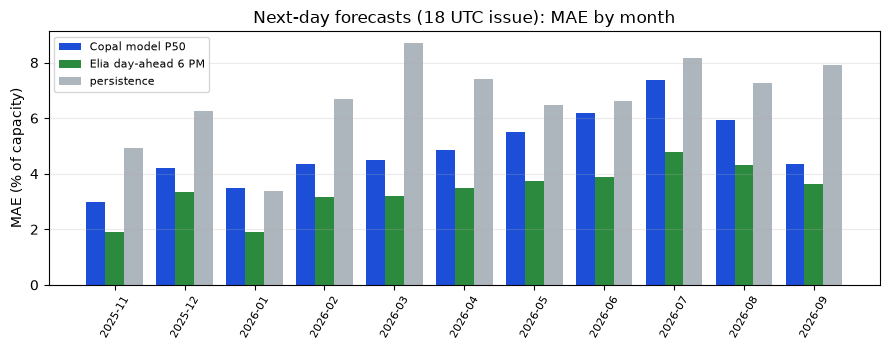

**Envelope sensitivity — whole test window**

slots  MAE (kW)  \
envelope                            block                        
envelope refitted on Elia (primary) intraday   40404    46.117   
                                    day_ahead  44166    48.946   
Copal envelope as-is                intraday   40404    44.834   
                                    day_ahead  44166    46.115   

                                               nMAE (% of capacity)  \
envelope                            block                             
envelope refitted on Elia (primary) intraday                  4.736   
                                    day_ahead                 5.026   
Copal envelope as-is                intraday                  4.604   
                                    day_ahead                 4.735   

                                               bias (kW)     R²  \
envelope                            block                         
envelope refitted on Elia (primary) intraday      14.640  0.854   
                                    day_ahead     19.268  0.831   
Copal envelope as-is                intraday      -4.363  0.860   
                                    day_ahead     -0.387  0.845   

                                               P10–P90 coverage (%)  \
envelope                            block                             
envelope refitted on Elia (primary) intraday                   68.4   
                                    day_ahead                  68.2   
Copal envelope as-is                intraday                   64.8   
                                    day_ahead                  65.2   

                                               skill vs persistence (%)  
envelope                            block                                
envelope refitted on Elia (primary) intraday                      34.23  
                                    day_ahead                     26.30  
Copal envelope as-is                intraday                      36.06  
                                    day_ahead                     30.56

In [10]:
da = leads[(leads.block == "day_ahead") & (leads.issue.dt.hour == 18)].copy()
ref = ELIA_DA.reindex(pd.DatetimeIndex(da.ts))
da["elia_p10"], da["elia_p50"], da["elia_p90"] = ref.p10.to_numpy(), ref.p50.to_numpy(), ref.p90.to_numpy()
da = da.dropna(subset=["elia_p50"])


def bench(g: pd.DataFrame) -> dict:
    a = g.actual.to_numpy()
    out = {}
    for name, col in (("Copal model P50 (18 UTC issue)", "p50"), ("Elia day-ahead 6 PM", "elia_p50"), ("persistence (24 h)", "pers")):
        err = g[col].to_numpy() - a
        out[name] = {"slots": len(g), "MAE (kW)": round(float(np.mean(np.abs(err))), 2),
                     "nMAE (% of capacity)": round(100 * float(np.mean(np.abs(err))) / CAPACITY_KWC, 2),
                     "bias (kW)": round(float(np.mean(err)), 2),
                     "R²": round(1 - float(np.sum(err ** 2)) / float(np.sum((a - a.mean()) ** 2)), 3)}
    out["Copal model P50 (18 UTC issue)"]["P10–P90 coverage (%)"] = round(100 * float(np.mean((g.p10 <= g.actual) & (g.actual <= g.p90))), 1)
    out["Elia day-ahead 6 PM"]["P10–P90 coverage (%)"] = round(100 * float(np.mean((g.elia_p10 <= g.actual) & (g.actual <= g.elia_p90))), 1)
    return out


frames = []
for label, g in [(WINDOWS[0], da[da.window == WINDOWS[0]]), (WINDOWS[1], da[da.window == WINDOWS[1]]), ("whole test window", da)]:
    f = pd.DataFrame(bench(g)).T
    f.index = pd.MultiIndex.from_product([[label], f.index], names=["window", "forecast"])
    frames.append(f)
bench_table = pd.concat(frames)
display(Markdown("**Next-day forecasts issued at 18 UTC on D-1 — same slots, same actuals**"))
display(bench_table)

fig, ax = plt.subplots(figsize=(9, 3.6))
mm = da.assign(month=da.ts.dt.strftime("%Y-%m"), model=(da.p50 - da.actual).abs(), elia=(da.elia_p50 - da.actual).abs(),
               persistence=(da.pers - da.actual).abs()).groupby("month")[["model", "elia", "persistence"]].mean() * 100 / CAPACITY_KWC
xx = np.arange(len(mm))
ax.bar(xx - 0.27, mm.model, 0.27, color="#1c4ed8", label="Copal model P50")
ax.bar(xx, mm.elia, 0.27, color="#2b8a3e", label="Elia day-ahead 6 PM")
ax.bar(xx + 0.27, mm.persistence, 0.27, color="#adb5bd", label="persistence")
ax.set_xticks(xx, mm.index, rotation=60, fontsize=8)
ax.set_ylabel("MAE (% of capacity)")
ax.set_title("Next-day forecasts (18 UTC issue): MAE by month")
ax.legend(fontsize=8)
ax.grid(alpha=0.25, axis="y")
fig.tight_layout()
plt.show()

sens = {}
for name, frame in (("envelope refitted on Elia (primary)", leads), ("Copal envelope as-is", leads_copal_env)):
    for block in BLOCKS:
        sens[(name, block)] = report(frame[frame.block == block])
sens_table = tabulate(sens, ["n", "mae_kw", "nmae_capacity_pct", "bias_kw", "r2", "coverage_p10_p90_pct", "skill_vs_persistence_pct"])
sens_table.index = pd.MultiIndex.from_tuples(sens_table.index, names=["envelope", "block"])
display(Markdown("**Envelope sensitivity — whole test window**"))
display(sens_table)

## 10 · Example forecasts

Three next-day packages (issued 18:00 UTC on D-1, spring–summer days of the new period), picked by a rule,
not by eye: the day with the highest, the lowest and the median mean clear-sky index between 1 Apr and
30 Sep 2026. P10–P90 is the model's band; Elia's day-ahead P50 and persistence are drawn for reference.

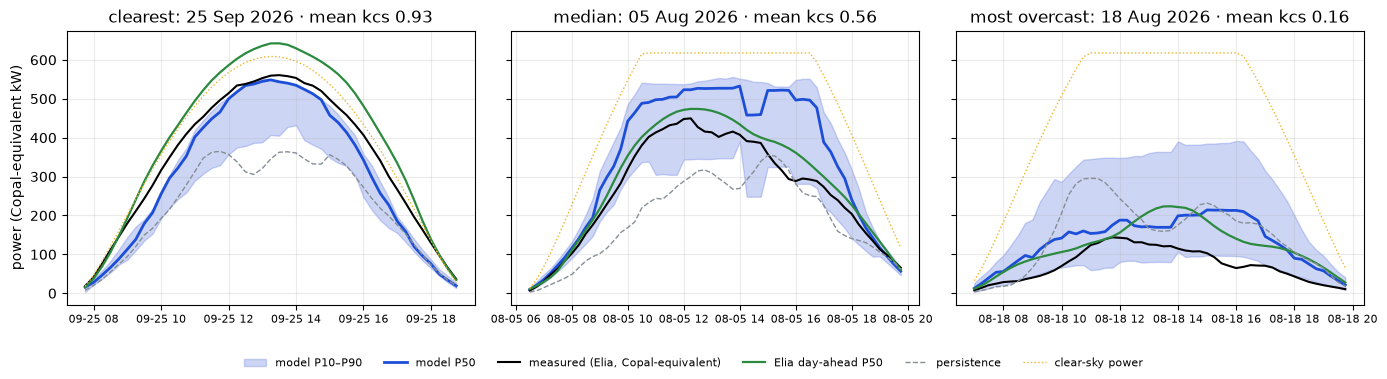

In [11]:
pk = da[(da.window == WINDOWS[1]) & (da.ts >= pd.Timestamp("2026-04-01", tz="UTC")) & (da.ts < pd.Timestamp("2026-10-01", tz="UTC"))].copy()
pk["day"] = pk.ts.dt.floor("D")
day_kcs_mean = pk.groupby("day").apply(lambda g: float((g.actual / g.clear_sky).mean()), include_groups=False)
day_kcs_mean = day_kcs_mean[pk.groupby("day").size() > 40]           # skip partial days
median_day = (day_kcs_mean - day_kcs_mean.median()).abs().idxmin()
picks = {"clearest": day_kcs_mean.idxmax(), "median": median_day, "most overcast": day_kcs_mean.idxmin()}

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, (label, day) in zip(axes, picks.items()):
    g = pk[pk.day == day].sort_values("ts")
    t = pd.DatetimeIndex(g.ts).tz_convert("Europe/Luxembourg")
    ax.fill_between(t, g.p10, g.p90, alpha=0.25, color="#3b5bdb", label="model P10–P90")
    ax.plot(t, g.p50, lw=2, color="#1c4ed8", label="model P50")
    ax.plot(t, g.actual, lw=1.5, color="black", label="measured (Elia, Copal-equivalent)")
    ax.plot(t, g.elia_p50, lw=1.6, color="#2b8a3e", label="Elia day-ahead P50")
    ax.plot(t, g.pers, lw=1, ls="--", color="#868e96", label="persistence")
    ax.plot(t, g.clear_sky, lw=1, ls=":", color="#f0b429", label="clear-sky power")
    ax.set_title(f"{label}: {day:%d %b %Y} · mean kcs {day_kcs_mean[day]:.2f}")
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(alpha=0.25)
axes[0].set_ylabel("power (Copal-equivalent kW)")
handles, labels = axes[0].get_legend_handles_labels()
fig.tight_layout(rect=[0, 0.09, 1, 1])
fig.legend(handles, labels, loc="lower center", ncol=6, fontsize=8, frameon=False)
plt.show()

## 11 · Summary

In [12]:
def line(block: str, window: str | None) -> dict:
    g = leads[leads.block == block] if window is None else leads[(leads.block == block) & (leads.window == window)]
    return report(g)


rows = []
for block in BLOCKS:
    rows.append((f"{block} — Copal plant, winter hold-out (gate)", report(copal_leads[copal_leads.block == block])))
    rows.append((f"{block} — Elia, same 60 days", line(block, WINDOWS[0])))
    rows.append((f"{block} — Elia, new period (to 30 Sep 2026)", line(block, WINDOWS[1])))
summary = ["| | slots | nMAE (% of capacity) | bias (kW) | R² | P10–P90 coverage (%) | skill vs persistence (%) | skill vs clear-sky persistence (%) |",
           "|---|---|---|---|---|---|---|---|"]
for name, s in rows:
    cs_skill = 100 * (1 - s["mae_kw"] / s["clear_sky_persistence_mae_kw"])
    summary.append(f"| {name} | {s['n']:,} | {s['nmae_capacity_pct']:.2f} | {s['bias_kw']:+.1f} | {s['r2']:.2f} | "
                   f"{s['coverage_p10_p90_pct']:.1f} | {s['skill_vs_persistence_pct']:+.1f} | {cs_skill:+.1f} |")
whole = bench_table.loc["whole test window"]
summary.append("")
summary.append(f"Next-day forecasts, whole test window ({int(whole.iloc[0]['slots']):,} slots): Copal day-ahead model "
               f"{whole.iloc[0]['nMAE (% of capacity)']:.2f} % nMAE vs Elia's own 6 PM forecast "
               f"{whole.iloc[1]['nMAE (% of capacity)']:.2f} % vs persistence {whole.iloc[2]['nMAE (% of capacity)']:.2f} %.")
summary.append("")
for block in BLOCKS:
    g = leads[leads.block == block]
    summary.append(f"Frozen conformal band, {block} (whole test window): P10–P90 coverage "
                   f"{100 * float(((g.p10 <= g.actual) & (g.actual <= g.p90)).mean()):.1f} % raw → "
                   f"{100 * float(((g.p10c <= g.actual) & (g.actual <= g.p90c)).mean()):.1f} % with the shipped offsets.")
display(Markdown("\n".join(summary)))


| | slots | nMAE (% of capacity) | bias (kW) | R² | P10–P90 coverage (%) | skill vs persistence (%) | skill vs clear-sky persistence (%) |
|---|---|---|---|---|---|---|---|
| intraday — Copal plant, winter hold-out (gate) | 5,265 | 1.69 | +2.5 | 0.58 | 69.7 | +33.8 | +30.9 |
| intraday — Elia, same 60 days | 5,265 | 3.43 | -12.2 | 0.55 | 53.6 | +31.8 | +12.2 |
| intraday — Elia, new period (to 30 Sep 2026) | 35,139 | 4.93 | +18.7 | 0.84 | 70.6 | +34.5 | +32.2 |
| day_ahead — Copal plant, winter hold-out (gate) | 5,253 | 1.74 | +1.1 | 0.55 | 70.3 | +31.1 | +31.3 |
| day_ahead — Elia, same 60 days | 5,302 | 3.76 | -11.3 | 0.49 | 50.3 | +25.7 | +26.9 |
| day_ahead — Elia, new period (to 30 Sep 2026) | 38,864 | 5.20 | +23.4 | 0.82 | 70.6 | +26.4 | +35.0 |

Next-day forecasts, whole test window (14,262 slots): Copal day-ahead model 5.22 % nMAE vs Elia's own 6 PM forecast 3.63 % vs persistence 7.01 %.

Frozen conformal band, intraday (whole test window): P10–P90 coverage 68.4 % raw → 77.8 % with the shipped offsets.
Frozen conformal band, day_ahead (whole test window): P10–P90 coverage 68.2 % raw → 79.1 % with the shipped offsets.

## 12 · Findings

Reference run: Elia data to 30 Sep 2026 (pinned), the shipped LightGBM models and `model_config.json`, no
scikit-learn. The gate in §4 reproduced the current release's published Copal hold-out, so everything below
comes from the same packaged models as `metrics.json`. The numbers quoted are those printed above; rerun the
notebook to regenerate them.

**1 · Skill on another source, in other seasons.** §6 and §7 are the point of this notebook: they take the
Copal-trained package to a regional series it has never seen and score it per window, per horizon, per month
and per season against 24 h persistence and clear-sky persistence. Read nMAE next to the mean capacity
factor of the same slots, since winter slots carry far less energy than summer ones.

**2 · Weather is the lever, and both forecasts have it.** §9 puts the packaged day-ahead model and Elia's own
6 PM forecast on the same slots and the same actuals, with Elia's cut two hours *earlier* than the shipped
18:00 UTC issue. What remains between them is the site-shape mismatch, not a missing input.

**3 · The transfer cost is mostly bias and shape.** On the same 60 days the Elia series is scored against the
gate's Copal hold-out. §8 shows why: the clear-day relation (PV ÷ clear-sky GHI as a function of clear-sky
GHI) can slope oppositely for a single well-oriented plant and for a fleet, and in months where Elia
out-produces Copal the forecasts under-forecast. That is why the card documents this as a Copal model, to be
refitted per site.

**4 · The envelope is the cheap half of a new-site calibration.** §9 runs the same boosters with the envelope
refitted on Elia against Copal's envelope as-is: it isolates what refitting the envelope alone buys, without
retraining the quantile models.

**What this does not show.**

* A Copal hold-out for spring and summer 2026: the Leneda export ends on 18 Jan 2026, so those months appear
  only through the Elia proxy.
* A decomposition of the transfer bias: §8's correlation is descriptive, and the monthly bias mixes the
  site-shape effect with each month's weather.
* A production band: the package ships frozen conformal offsets; a service with a feed of recent outcomes
  should update them online (main notebook §6).
